In [2]:
pip install tensorflow  


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier



In [4]:
# Step 2: Load Dataset
df = pd.read_csv(r"C:\Users\Admin\Downloads\X78.csv")
print(df.head())


   TopDepth  BotDepth     _CAL      _GR      _SP      _LLD      _LLS      _AC  \
0   1005.37   1006.94  10.5385  108.298  6.04385  19.75990  23.04980  103.977   
1   1006.94   1011.49  10.4860  137.953  5.48483  52.23740  49.00980  105.807   
2   1011.49   1013.45  10.7762  134.938  4.85190   7.32856   6.82943  107.791   
3   1013.45   1014.33  10.6042  145.568  4.89644  11.66790  12.88550  110.725   
4   1014.33   1015.47  10.6950  139.278  4.89361   7.71140   7.13805  111.684   

      _DEN      _PEF Lith_Section  
0  2.22713  0.884914     mudstone  
1  2.10433  0.884625    oil shale  
2  2.24680  0.883637     mudstone  
3  2.16336  0.883922    oil shale  
4  2.18642  0.884409     mudstone  


In [5]:
# Step 3: Features & Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [6]:
# Step 4: Handle Missing Values
X = X.fillna(X.mean())

In [7]:

# Step 5: Encode Target (VERY IMPORTANT)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [8]:
# Step 6: Scaling (optional but keeping same format)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:

# Step 7: Train XGBoost Model (FULL DATA)
xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',   # Correct for multi-class
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist'   # faster (optional)
)

xgb.fit(X_scaled, y_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:

# Step 8: Prediction
y_pred = xgb.predict(X_scaled)

In [11]:
# Step 9: Accuracy
print("XGBoost Accuracy (Full Data):", accuracy_score(y_encoded, y_pred))

XGBoost Accuracy (Full Data): 1.0


In [12]:
# Step 10: Classification Report
print("\nClassification Report:\n",
      classification_report(y_encoded, y_pred, target_names=le.classes_))


Classification Report:
                  precision    recall  f1-score   support

muddy siltstone       1.00      1.00      1.00        88
       mudstone       1.00      1.00      1.00       365
      oil shale       1.00      1.00      1.00        13
      siltstone       1.00      1.00      1.00        97
 silty mudstone       1.00      1.00      1.00        98

       accuracy                           1.00       661
      macro avg       1.00      1.00      1.00       661
   weighted avg       1.00      1.00      1.00       661



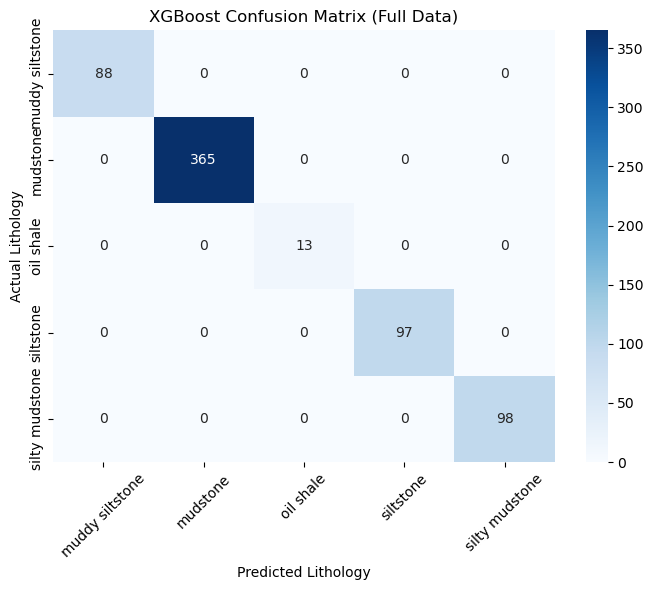

In [18]:
# Step 11: Confusion Matrix
cm = confusion_matrix(y_encoded, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("XGBoost Confusion Matrix (Full Data)")
plt.xlabel("Predicted Lithology")
plt.ylabel("Actual Lithology")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()